##**Project**: **Sowing Success** 🌾

*Predicting Optimal Crops through Soil Analytics*



---


**Background**

In agriculture, choosing the right crop for the right soil is the difference between profit and loss. However, measuring every soil metric (N, P, K, and pH) can be expensive and time-consuming. This project aims to assist farmers by using machine learning to predict the most suitable crop for their field based on these key soil elements.

**The Mission**

Using a dataset of soil measurements (soil_measures.csv), my goal is to:

Build a Multi-class Classifier: Train a model to accurately identify which of the 22 crops should be planted based on soil conditions.

Identify the Key Predictor: Determine which single soil feature (Nitrogen, Phosphorous, Potassium, or pH) provides the strongest predictive power to help farmers prioritize their testing budget.

**Data Dictionary**

N, P, K: Ratios of Nitrogen, Phosphorous, and Potassium in the soil.

pH: The acidity/alkalinity level of the soil.

Crop: The optimal target variable for each field.

In [24]:
#Required libraries are imported
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [25]:
#mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# Load the dataset
file_path = '/content/drive/MyDrive/Data Science Projects/soil_measures.csv'
crops = pd.read_csv(file_path)

In [27]:
#dispaly the first 5 rows
crops.head()

,N,P,K,ph,crop
0,90,42,43,6.502985,rice
1,85,58,41,7.038096,rice
2,60,55,44,7.840207,rice
3,74,35,40,6.980401,rice
4,78,42,42,7.628473,rice


In [28]:
#display the data information, data structure etc.
crops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       2200 non-null   int64  
 1   P       2200 non-null   int64  
 2   K       2200 non-null   int64  
 3   ph      2200 non-null   float64
 4   crop    2200 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 86.1+ KB


In [29]:
#display statistical summary
crops.describe()

,N,P,K,ph
count,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,6.469480
std,36.917334,32.985883,50.647931,0.773938
min,0.000000,5.000000,5.000000,3.504752
25%,21.000000,28.000000,20.000000,5.971693
50%,37.000000,51.000000,32.000000,6.425045
75%,84.250000,68.000000,49.000000,6.923643
max,140.000000,145.000000,205.000000,9.935091


In [30]:
#checking data shape
crops.shape

(2200, 5)

In [31]:
#checking possible duplicate values
crops.duplicated().sum()

np.int64(0)

In [32]:
#checking null values
crops.isnull().sum()

,0
N,0
P,0
K,0
ph,0
crop,0


In [33]:
#checking the values in the target variable
crops['crop'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

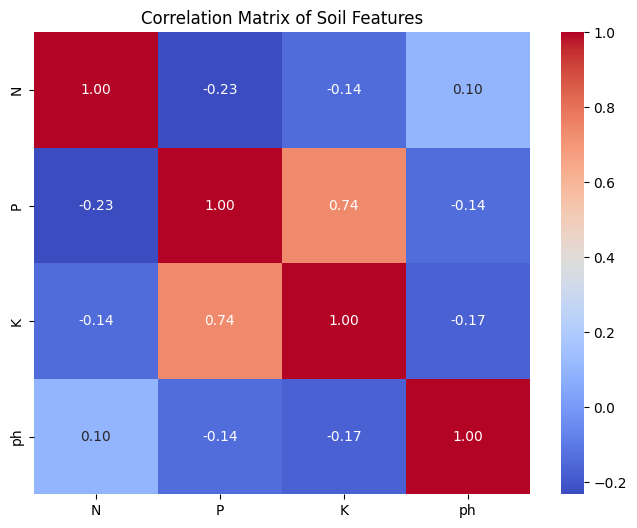

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

#Calculate the correlation numbers
# .corr() defaults to 'pearson' correlation
corr_matrix = crops[['N', 'P', 'K', 'ph']].corr()
#Create the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Soil Features")
plt.show()


In [35]:
#encoding the Target Variable
#Create a dictionary automatically from your unique values
crop_list = ['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
             'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
             'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
             'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee']

crop_map = {crop: i for i, crop in enumerate(crop_list)}

#Map it just like you did with the diagnosis column
crops['crop'] = crops['crop'].map(crop_map)

#Check the results
print(crops['crop'].value_counts())

crop
0     100
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
20    100
21    100
Name: count, dtype: int64


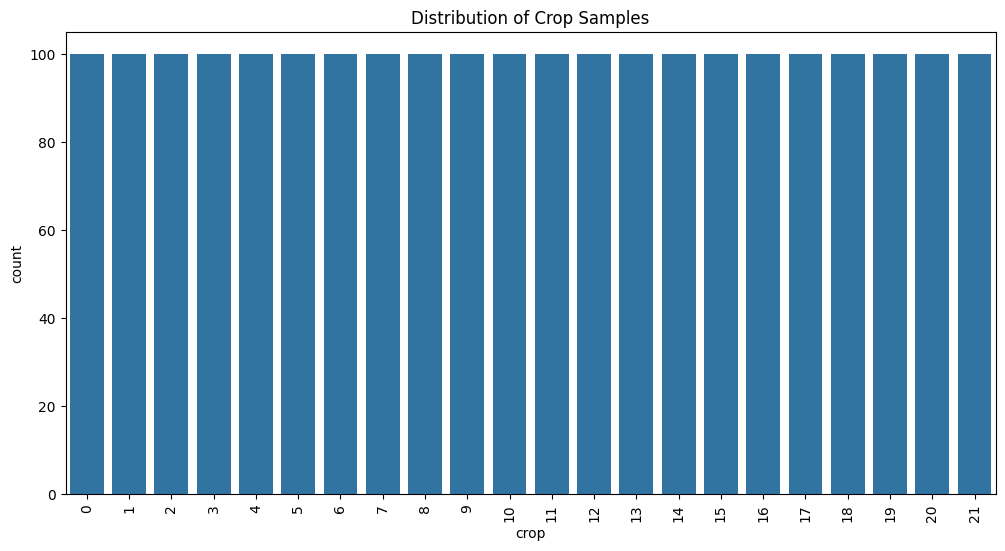

In [36]:
plt.figure(figsize=(12,6))
sns.countplot(x='crop', data=crops)
plt.title("Distribution of Crop Samples")
plt.xticks(rotation=90) # Rotates the labels so they don't overlap
plt.show()

In [37]:
#declaring Features and Target Variables
X = crops.drop('crop', axis=1)
y = crops['crop']

In [38]:
# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#scalling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# We "Fit" the scaler on the training data ONLY to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)

# We "Transform" the test data using the same rules
X_test_scaled = scaler.transform(X_test)

##Model 1: Logistic Regression

In [39]:
# Create and train the model
# multi_class='auto' will handle your 22 crops automatically
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train_scaled, y_train)

# Make predictions on the hidden test set
y_pred = model.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [40]:
from sklearn.metrics import classification_report, confusion_matrix
# This prints Precision, Recall, and F1-Score for EVERY crop
print(classification_report(y_test, y_pred, target_names=crop_list))

              precision    recall  f1-score   support

        rice       0.38      0.32      0.34        19
       maize       0.91      1.00      0.95        21
    chickpea       1.00      0.77      0.87        26
 kidneybeans       0.45      0.65      0.53        20
  pigeonpeas       0.18      0.09      0.12        23
   mothbeans       0.60      0.25      0.35        24
    mungbean       0.67      0.74      0.70        19
   blackgram       0.76      0.65      0.70        20
      lentil       0.30      0.64      0.41        11
 pomegranate       0.69      0.87      0.77        23
      banana       1.00      1.00      1.00        21
       mango       0.40      0.53      0.45        19
      grapes       0.45      0.93      0.60        14
  watermelon       0.73      0.58      0.65        19
   muskmelon       0.62      0.76      0.68        17
       apple       0.88      0.30      0.45        23
      orange       1.00      1.00      1.00        14
      papaya       0.74    

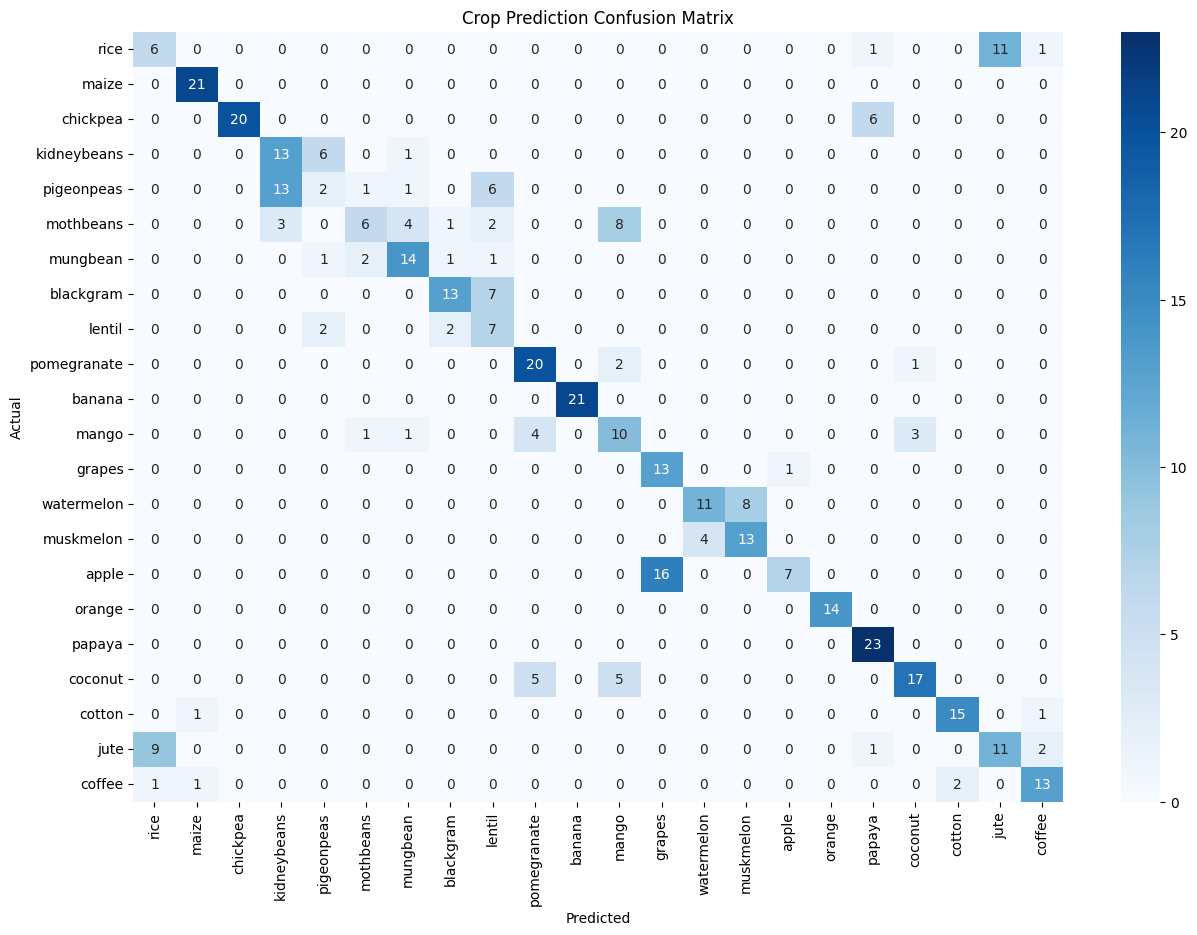

In [41]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(15,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=crop_list, yticklabels=crop_list)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Crop Prediction Confusion Matrix')
plt.show()

##Model 2: Support Vector Machine

In [42]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [43]:
#Initialize SVM with the RBF kernel
# C=1 is a good balance between 'simple' and 'complex'
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')

#Train the model using your scaled data
svm_model.fit(X_train_scaled, y_train)

#Predict
y_pred_svm = svm_model.predict(X_test_scaled)

#Check the new accuracy
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}")
print(classification_report(y_test, y_pred_svm, target_names=crop_list))

SVM Accuracy: 0.73
              precision    recall  f1-score   support

        rice       0.67      0.21      0.32        19
       maize       0.95      0.90      0.93        21
    chickpea       1.00      1.00      1.00        26
 kidneybeans       0.62      1.00      0.77        20
  pigeonpeas       0.86      0.26      0.40        23
   mothbeans       1.00      0.54      0.70        24
    mungbean       0.70      0.84      0.76        19
   blackgram       0.72      0.65      0.68        20
      lentil       0.30      0.64      0.41        11
 pomegranate       0.75      0.65      0.70        23
      banana       1.00      1.00      1.00        21
       mango       0.59      0.53      0.56        19
      grapes       0.43      0.93      0.59        14
  watermelon       0.67      0.42      0.52        19
   muskmelon       0.54      0.76      0.63        17
       apple       0.86      0.26      0.40        23
      orange       1.00      1.00      1.00        14
      pa

In [ ]:
from sklearn.metrics import f1_score

features = ['N', 'P', 'K', 'ph']
feature_performance = {}

for feature in features:
    # Train a simple model on just one column
    X_single = X_train[[feature]]
    X_test_single = X_test[[feature]]

    # We don't necessarily need scaling for a single feature, but it's good practice
    # Increased max_iter to address ConvergenceWarning
    model_single = LogisticRegression(max_iter=10000)
    model_single.fit(X_single, y_train)

    # Evaluate
    y_pred_single = model_single.predict(X_test_single)
    score = f1_score(y_test, y_pred_single, average='weighted')

    feature_performance[feature] = score

# Find the winner
best_feature_name = max(feature_performance, key=feature_performance.get)
best_predictive_feature = {best_feature_name: feature_performance[best_feature_name]}

print(f"The MVP feature is: {best_predictive_feature}")


##Conclusion
This analysis demonstrates that machine learning can effectively guide agricultural decisions by identifying the relationship between soil chemistry and crop suitability.

##Key Insights
**Model Performance**: Our initial Logistic Regression model provided a baseline accuracy of 66%. By moving to a non-linear Support Vector Machine (SVM), we improved predictive accuracy to 73%, showing that the relationship between nutrients and crop types is complex and non-linear.

**The MVP Feature**: Through individual feature testing, Potassium (K) emerged as the single most important predictor for crop classification. This suggests that for farmers on a strict budget, prioritizing Potassium testing provides the most significant "bang for their buck" in determining what to plant.

**Data Overlap**: The remaining 27% of error in our model is largely due to "Problem Pairs" like Rice and Jute, which share very similar soil signatures. To improve this further, adding climate data (like rainfall or temperature) would likely bridge that gap.

##Final Recommendation
For this specific dataset, we recommend using the SVM model for crop selection. However, farmers should prioritize monitoring Potassium levels as the primary indicator for distinguishing between diverse crop varieties.